# p3_noise_3 — λ_CNOT × λ_meas sweep (custom Aer noise, N=4)

`make_noise_model()` (depolarizing + idle `id` + Pauli reset) 기반 self-contained 스윕.
Fake backend / T1·T2 thermal noise 없음.


In [1]:

from __future__ import annotations

import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

try:
    import mthree
except ModuleNotFoundError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "mthree"])
    import mthree

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import IfElseOp, Reset
from qiskit.circuit.classical import expr
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, pauli_error

SHOTS = 1024
SEED = 1557
np.random.seed(SEED)


# ------------------------- Custom Aer noise model (no fake backend) -------------------------
@dataclass(frozen=True)
class BaseNoiseParams:
    one_qubit_error: float = 0.001
    idle_error: float = 0.001
    two_qubit_error: float = 0.01
    reset_error: float = 0.01
    readout_error: float = 0.01


BASE_NOISE = BaseNoiseParams()
SIM_BACKEND_NAME = "aer_custom_noise"


def make_noise_model(
    one_qubit_error=0.001,
    idle_error=0.001,
    two_qubit_error=0.01,
    reset_error=0.01,
    readout_error=0.01,
):
    noise_model = NoiseModel()

    error_1q = depolarizing_error(one_qubit_error, 1)
    error_idle = depolarizing_error(idle_error, 1)
    error_2q = depolarizing_error(two_qubit_error, 2)
    error_reset = pauli_error([("X", reset_error), ("I", 1 - reset_error)])
    error_readout = ReadoutError(
        [
            [1 - readout_error, readout_error],
            [readout_error, 1 - readout_error],
        ]
    )

    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ["h", "x", "y", "z", "sdg", "sx"],
    )
    noise_model.add_all_qubit_quantum_error(error_idle, ["id"])
    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])
    noise_model.add_all_qubit_quantum_error(error_reset, ["reset"])
    noise_model.add_all_qubit_readout_error(error_readout)
    return noise_model


noise_model = make_noise_model(**BASE_NOISE.__dict__)
simulator = AerSimulator(noise_model=noise_model, seed_simulator=SEED)

SIM_BACKEND = AerSimulator()
SIM_BACKEND.set_options(seed_simulator=SEED)
if "if_else" not in SIM_BACKEND.target.operation_names:
    SIM_BACKEND.target.add_instruction(IfElseOp, name="if_else")
if "reset" not in SIM_BACKEND.target.operation_names:
    SIM_BACKEND.target.add_instruction(Reset, name="reset")


def _clip_probability(value: float, upper: float = 1.0) -> float:
    return min(max(float(value), 0.0), upper)


# ------------------------- LRCX circuits + fidelity metric -------------------------

def check_even(n: int) -> int:
    return 1 if n % 2 == 0 else 2


def initialize_circuit(distance: int) -> QuantumCircuit:
    assert distance >= 0
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    k = int(n / 2)
    allcr = [cr]
    if distance > 1:
        allcr.append(ClassicalRegister(k, name="c1"))
    if distance > 0:
        allcr.append(ClassicalRegister(n - k, name="c2"))
    qc = QuantumCircuit(qr, *allcr, name="LRCX")
    qc.h(0)
    return qc


def prepare_bell_pairs(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = int(n / 2)
    if add_barriers:
        qc.barrier()
    x0 = check_even(n)
    if n % 2 != 0:
        qc.cx(0, 1)
    for i in range(k):
        qc.h(x0 + 2 * i)
        qc.cx(x0 + 2 * i, x0 + 2 * i + 1)
    return qc


def reset_measured_ancillas(qc: QuantumCircuit, add_barrier: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    if n <= 0:
        return qc
    if add_barrier:
        qc.barrier()
    for q in range(1, n + 1):
        qc.reset(q)
    return qc


def measure_bell_basis(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = int(n / 2)
    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs
    x0 = 1 if n % 2 == 0 else 2
    for i in range(k + 1):
        qc.cx(x0 - 1 + 2 * i, x0 + 2 * i)
    for i in range(1, k + x0):
        qc.h(2 * i + 1 - x0)
    if add_barriers:
        qc.barrier()
    for i in range(k):
        qc.measure(2 * i + x0, c1[i])
    for i in range(1, k + x0):
        qc.measure(2 * i + 1 - x0, c2[i - 1])
    reset_measured_ancillas(qc, add_barrier=add_barriers)
    return qc


def apply_ffwd_corrections(qc: QuantumCircuit) -> QuantumCircuit:
    control, target = 0, qc.num_qubits - 1
    n = qc.num_qubits - 2
    k = int(n / 2)
    x0 = check_even(n)
    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs

    for i in range(k):
        if i == 0:
            parity_ZZ = expr.lift(c1[i])
        else:
            parity_ZZ = expr.bit_xor(c1[i], parity_ZZ)

    for i in range(1, k + x0):
        if i == 1:
            parity_XX = expr.lift(c2[i - 1])
        else:
            parity_XX = expr.bit_xor(c2[i - 1], parity_XX)

    if n > 0:
        with qc.if_test(parity_XX):
            qc.z(control)
    if n > 1:
        with qc.if_test(parity_ZZ):
            qc.x(target)
    return qc


def measure_in_basis(qc: QuantumCircuit, basis: str = "XX", add_barrier: bool = True) -> QuantumCircuit:
    assert basis in ["XX", "YY", "ZZ"]
    qc = qc.copy()
    cr = qc.cregs[0]
    control, target = 0, qc.num_qubits - 1
    if add_barrier:
        qc.barrier()
    if basis == "XX":
        qc.h(control)
        qc.h(target)
    elif basis == "YY":
        qc.sdg(control)
        qc.sdg(target)
        qc.h(control)
        qc.h(target)
    qc.measure(control, cr[0])
    qc.measure(target, cr[1])
    return qc


def lrcx(distance: int, prep_barrier: bool = False, pre_measure_barrier: bool = False) -> QuantumCircuit:
    qc = initialize_circuit(distance)
    qc = prepare_bell_pairs(qc, prep_barrier)
    qc = measure_bell_basis(qc, pre_measure_barrier)
    qc = apply_ffwd_corrections(qc)
    return qc


def cnot_unitary_swap(distance: int) -> QuantumCircuit:
    assert distance >= 0
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    qc = QuantumCircuit(qr, cr, name="CNOT_unitary")
    qc.h(0)
    k = int(n / 2)
    qc.barrier()
    for i in range(k):
        qc.cx(i, i + 1)
        qc.cx(i + 1, i)
        qc.cx(-i - 1, -i - 2)
        qc.cx(-i - 2, -i - 1)
    if n % 2 == 1:
        qc.cx(k + 2, k + 1)
        qc.cx(k + 1, k + 2)
    qc.barrier()
    qc.cx(k, k + 1)
    for i in range(k):
        qc.cx(k - i, k - 1 - i)
        qc.cx(k - 1 - i, k - i)
        qc.cx(k + i + 1, k + i + 2)
        qc.cx(k + i + 2, k + i + 1)
    if n % 2 == 1:
        qc.cx(-2, -1)
        qc.cx(-1, -2)
    return qc


def certification_circuits(distance: int, mode: str = "dynamic"):
    builder = lrcx if mode == "dynamic" else cnot_unitary_swap
    core = builder(distance)
    return [measure_in_basis(core, basis=b) for b in ["XX", "YY", "ZZ"]]


CNOT_PROCESS_DIM = 4


def compute_ZZ_expectation(counts: dict) -> float:
    total = sum(counts.values())
    if total == 0:
        return 0.0
    exp = 0.0
    for bitstring, count in counts.items():
        z1 = (-1) ** int(bitstring[-1])
        z2 = (-1) ** int(bitstring[-2])
        exp += z1 * z2 * count
    return exp / total


def compute_process_fidelity(counts_xx, counts_yy, counts_zz) -> float:
    xx, yy, zz = [compute_ZZ_expectation(c) for c in [counts_xx, counts_yy, counts_zz]]
    return 0.25 * (1 + xx - yy + zz)


def compute_average_gate_fidelity(counts_xx, counts_yy, counts_zz, d: int = CNOT_PROCESS_DIM) -> float:
    f_proc = compute_process_fidelity(counts_xx, counts_yy, counts_zz)
    return (d * f_proc + 1) / (d + 1)


def compute_fidelity(counts_xx, counts_yy, counts_zz) -> float:
    return compute_average_gate_fidelity(counts_xx, counts_yy, counts_zz)


# ------------------------- M3 readout mitigation (dynamic_cnot_qem_mthree style) -------------------------
APPLY_READOUT_MITIGATION = True
USE_REAL_HARDWARE = False

_M3_EXEC_BACKEND = None


def get_m3_execution_backend():
    global _M3_EXEC_BACKEND
    if _M3_EXEC_BACKEND is None:
        _M3_EXEC_BACKEND = AerSimulator()
    return _M3_EXEC_BACKEND


def cr_qubit_mapping(layout: list[int]) -> list[int]:
    """Physical qubits for 2-bit cr (control=layout[0], target=layout[-1])."""
    return [layout[0], layout[-1]]


def _symmetric_readout_cal_matrix(readout_error: float) -> np.ndarray:
    p = _clip_probability(readout_error, upper=0.5)
    return np.array([[1.0 - p, p], [p, 1.0 - p]], dtype=np.float64)


def build_m3_mitigator(layout: list[int], readout_error: float):
    """Build M3 mitigator with cals matching the swept readout error."""
    exec_backend = get_m3_execution_backend()
    mit = mthree.M3Mitigation(exec_backend)
    cal = _symmetric_readout_cal_matrix(readout_error)
    matrices = [None] * exec_backend.num_qubits
    for q in cr_qubit_mapping(layout):
        matrices[q] = cal
    mit.cals_from_matrices(matrices)
    return mit


def compute_ZZ_expectation_quasi(quasis) -> float:
    total = sum(quasis.values())
    if total == 0:
        return 0.0
    expectation = 0.0
    for bitstring, weight in quasis.items():
        bits = bitstring.replace(" ", "")[-2:]
        z1 = (-1) ** int(bits[-1])
        z2 = (-1) ** int(bits[-2])
        expectation += z1 * z2 * weight
    return expectation / total


def compute_fidelity_from_quasi(quasis_xx, quasis_yy, quasis_zz) -> float:
    xx, yy, zz = [compute_ZZ_expectation_quasi(q) for q in (quasis_xx, quasis_yy, quasis_zz)]
    f_proc = 0.25 * (1 + xx - yy + zz)
    return (CNOT_PROCESS_DIM * f_proc + 1) / (CNOT_PROCESS_DIM + 1)


def extract_cr_counts(counts: dict) -> dict:
    """Marginalize Aer counts to the 2-bit cr register (rightmost bits)."""
    cr_counts = {}
    for bitstring, count in counts.items():
        key = bitstring.replace(" ", "")[-2:]
        cr_counts[key] = cr_counts.get(key, 0) + count
    return cr_counts


def m3_correct_counts(mit, counts, layout):
    return mit.apply_correction(extract_cr_counts(counts), cr_qubit_mapping(layout))


def m3_fidelity_triplet(mit, counts_xx, counts_yy, counts_zz, layout) -> float:
    q_xx = m3_correct_counts(mit, counts_xx, layout)
    q_yy = m3_correct_counts(mit, counts_yy, layout)
    q_zz = m3_correct_counts(mit, counts_zz, layout)
    return compute_fidelity_from_quasi(q_xx, q_yy, q_zz)


# ------------------------- Lambda sweep helpers (N=4 only) -------------------------
LAMBDA_GRID_POINTS = 7


def _lambda_to_probability(lam: float) -> float:
    return min(1.0 - 1e-12, 1.0 - math.exp(-float(lam)))


def make_lambda_grids(n_points: int = LAMBDA_GRID_POINTS):
    ref_gate = BASE_NOISE.two_qubit_error
    ref_ro = BASE_NOISE.readout_error
    lc = -math.log(1 - ref_gate)
    lm = -math.log(1 - ref_ro)
    lambda_cnot_grid = np.linspace(max(0.25 * lc, 1e-4), 3.0 * lc, n_points)
    lambda_meas_grid = np.linspace(max(0.25 * lm, 1e-4), 3.0 * lm, n_points)
    base_params = {"lambda_cnot": lc, "lambda_meas": lm}
    return lambda_cnot_grid, lambda_meas_grid, base_params






def error_budget_resources(core: QuantumCircuit) -> dict:
    ops = dict(core.count_ops())
    return {
        "N_CNOT": float(ops.get("cx", 0) + ops.get("ecr", 0)),
        "N_meas": float(ops.get("measure", 0)),
        "t_idle": 0.0,
    }


def compute_lambda_total(resources: dict, params: dict) -> float:
    return resources["N_CNOT"] * params["lambda_cnot"] + resources["N_meas"] * params["lambda_meas"]


def budget_params_with_lambdas(base_params: dict, lambda_cnot: float, lambda_meas: float) -> dict:
    out = dict(base_params)
    out["lambda_cnot"] = float(lambda_cnot)
    out["lambda_meas"] = float(lambda_meas)
    return out


def noise_params_from_lambdas(lambda_cnot: float, lambda_meas: float) -> dict[str, float]:
    p_cnot = _lambda_to_probability(lambda_cnot)
    p_meas = _lambda_to_probability(lambda_meas)
    ref_2q = BASE_NOISE.two_qubit_error
    scale = p_cnot / ref_2q if ref_2q > 0 else 1.0
    return {
        "one_qubit_error": _clip_probability(BASE_NOISE.one_qubit_error * scale),
        "idle_error": _clip_probability(BASE_NOISE.idle_error * scale),
        "two_qubit_error": _clip_probability(p_cnot),
        "reset_error": BASE_NOISE.reset_error,
        "readout_error": _clip_probability(p_meas),
    }



# Cache transpiled certification circuits once (per kernel).
# IMPORTANT: cache key must include circuit signature (dynamic vs unitary differ).
_TC_CACHE: dict[tuple[str, tuple], list[QuantumCircuit]] = {}


def _cert_signature(cert_circs) -> tuple:
    sig = []
    for c in cert_circs:
        ops = tuple(sorted(dict(c.count_ops()).items()))
        sig.append((c.num_qubits, c.num_clbits, ops))
    return tuple(sig)


def run_certification_fidelity(
    noise_params: dict[str, float],
    cert_circs,
    *,
    layout: list[int] | None = None,
    apply_m3: bool = False,
) -> float:
    # 1) Transpile once for this backend + circuit signature.
    key = (SIM_BACKEND_NAME, _cert_signature(cert_circs))
    if key not in _TC_CACHE:
        # transpile without noise; basis/coupling only.
        _TC_CACHE[key] = [transpile(c, SIM_BACKEND, optimization_level=0) for c in cert_circs]

    tc = _TC_CACHE[key]

    sweep_noise = make_noise_model(**noise_params)
    sim = AerSimulator(noise_model=sweep_noise, seed_simulator=SEED)

    counts_xx = extract_cr_counts(sim.run(tc[0], shots=SHOTS).result().get_counts())
    counts_yy = extract_cr_counts(sim.run(tc[1], shots=SHOTS).result().get_counts())
    counts_zz = extract_cr_counts(sim.run(tc[2], shots=SHOTS).result().get_counts())

    if apply_m3 and APPLY_READOUT_MITIGATION and layout is not None:
        m3_mit = build_m3_mitigator(layout, noise_params["readout_error"])
        return m3_fidelity_triplet(m3_mit, counts_xx, counts_yy, counts_zz, layout)
    return compute_fidelity(counts_xx, counts_yy, counts_zz)


def assign_chain_for_topology(n_logical: int) -> list[int]:
    # Minimal heavy-hex proxy: just take first n_logical qubits
    return list(range(n_logical))


def sweep_lambda_cnot_meas_heatmaps(
    distance: int,
    lambda_cnot_grid=None,
    lambda_meas_grid=None,
    *,
    apply_m3: bool = False,
):
    n_logical = distance + 2
    chain = assign_chain_for_topology(n_logical)

    cert_dyn = certification_circuits(distance, mode="dynamic")
    cert_uni = certification_circuits(distance, mode="unitary")

    resources_dyn = error_budget_resources(cert_dyn[0])
    resources_uni = error_budget_resources(cert_uni[0])

    if lambda_cnot_grid is None or lambda_meas_grid is None:
        lambda_cnot_grid, lambda_meas_grid, base_params = make_lambda_grids()
    else:
        base_params = {"lambda_cnot": float(lambda_cnot_grid[0]), "lambda_meas": float(lambda_meas_grid[0])}

    fidelity_dyn = np.zeros((len(lambda_meas_grid), len(lambda_cnot_grid)))
    fidelity_uni = np.zeros_like(fidelity_dyn)
    lambda_dyn = np.zeros_like(fidelity_dyn)
    lambda_uni = np.zeros_like(fidelity_dyn)

    n_points = len(lambda_cnot_grid) * len(lambda_meas_grid)

    m3_tag = " + M3 readout mitigation" if apply_m3 else ""
    print(f"\nCustom Aer noise{m3_tag} | backend={SIM_BACKEND_NAME} | distance n={distance}")
    print(
        f"  resources (dynamic): t_idle={resources_dyn['t_idle']:.2f}, N_CNOT={resources_dyn['N_CNOT']:.0f}, N_meas={resources_dyn['N_meas']:.0f}"
    )
    print(
        f"  resources (unitary): t_idle={resources_uni['t_idle']:.2f}, N_CNOT={resources_uni['N_CNOT']:.0f}, N_meas={resources_uni['N_meas']:.0f}"
    )
    print("  dynamic core ops:", dict(cert_dyn[0].count_ops()))
    print("  unitary core ops:", dict(cert_uni[0].count_ops()))
    print(
        f"  lambda_CNOT grid: {np.round(lambda_cnot_grid, 5).tolist()}\n  lambda_meas grid: {np.round(lambda_meas_grid, 5).tolist()}"
    )

    for i, lambda_meas in enumerate(lambda_meas_grid):
        for j, lambda_cnot in enumerate(lambda_cnot_grid):
            budget_params = budget_params_with_lambdas(base_params, lambda_cnot, lambda_meas)
            lambda_dyn[i, j] = compute_lambda_total(resources_dyn, budget_params)
            lambda_uni[i, j] = compute_lambda_total(resources_uni, budget_params)

            sweep_noise_params = noise_params_from_lambdas(lambda_cnot, lambda_meas)
            fidelity_dyn[i, j] = run_certification_fidelity(
                sweep_noise_params,
                cert_dyn,
                layout=chain,
                apply_m3=apply_m3,
            )
            fidelity_uni[i, j] = run_certification_fidelity(
                sweep_noise_params,
                cert_uni,
                layout=chain,
                apply_m3=apply_m3,
            )

            point = i * len(lambda_cnot_grid) + j + 1
            if point % max(1, n_points // 6) == 0 or point == n_points:
                print(
                    f"  progress {point}/{n_points} | λ_CNOT={lambda_cnot:.5f}, λ_meas={lambda_meas:.5f}, F_dyn={fidelity_dyn[i, j]:.3f}, F_uni={fidelity_uni[i, j]:.3f}"
                )

    meta = {
        "backend_name": SIM_BACKEND_NAME,
        "display_name": "Custom Aer noise",
        "distance": distance,
        "lambda_cnot_grid": lambda_cnot_grid,
        "lambda_meas_grid": lambda_meas_grid,
        "base_budget_params": base_params,
        "apply_m3": apply_m3,
    }
    return fidelity_dyn, fidelity_uni, lambda_dyn, lambda_uni, meta


def plot_lambda_cnot_meas_heatmaps(
    fidelity_map: np.ndarray,
    lambda_map: np.ndarray,
    meta: dict,
    *,
    variant: str = "Dynamic LRCX",
    realistic_region: tuple[float, float, float, float] | None = None,
) -> None:
    lambda_cnot_grid = meta["lambda_cnot_grid"]
    lambda_meas_grid = meta["lambda_meas_grid"]
    extent = [lambda_cnot_grid[0], lambda_cnot_grid[-1], lambda_meas_grid[0], lambda_meas_grid[-1]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    panels = [
        (fidelity_map, "Average gate fidelity", "Average gate fidelity (F_avg)"),
        (lambda_map, "lambda_tot", "lambda_tot"),
    ]

    for ax, (data, title, cbar_label) in zip(axes, panels):
        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap="gray",
            vmin=float(np.min(data)),
            vmax=float(np.max(data)),
        )
        ax.set_xlabel("lambda_CNOT")
        ax.set_ylabel("lambda_meas")
        ax.set_title(
            f"{title} | {variant} | n={meta['distance']} | {meta['display_name']}\nbackend: {meta['backend_name']}"
        )
        ax.grid(True, color="0.55", alpha=0.35, linestyle=":")

        if realistic_region is not None:
            from matplotlib.patches import Rectangle
            x0, x1, y0, y1 = realistic_region
            rect = Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                facecolor="yellow",
                edgecolor="white",
                linewidth=1.0,
                alpha=0.25,
                zorder=3,
            )
            ax.add_patch(rect)
            ax.text(
                x0,
                y1,
                " realistic hw range",
                color="white",
                fontsize=8,
                va="bottom",
                ha="left",
                zorder=4,
            )

        # guideline: lambda_meas = 3 * lambda_CNOT
        x_min, x_max, y_min, y_max = extent
        xs = np.linspace(x_min, x_max, 200)
        ys = 3.0 * xs
        m = (ys >= y_min) & (ys <= y_max)
        if np.any(m):
            ax.plot(xs[m], ys[m], color="cyan", linewidth=1.5, linestyle="--", zorder=4)
            ax.text(
                xs[m][len(xs[m]) // 2],
                ys[m][len(ys[m]) // 2],
                "  λ_meas = 3·λ_CNOT",
                color="cyan",
                fontsize=8,
                ha="left",
                va="bottom",
                zorder=5,
            )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    fig.suptitle(
        f"{variant}: x=lambda_CNOT, y=lambda_meas (low=black, high=white)",
        y=1.02,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


def plot_lambda_fidelity_winner_heatmap(
    fidelity_dyn: np.ndarray,
    fidelity_uni: np.ndarray,
    meta: dict,
    realistic_region: tuple[float, float, float, float] | None = None,
) -> None:
    from matplotlib.patches import Patch, Rectangle

    lambda_cnot_grid = meta["lambda_cnot_grid"]
    lambda_meas_grid = meta["lambda_meas_grid"]
    extent = [lambda_cnot_grid[0], lambda_cnot_grid[-1], lambda_meas_grid[0], lambda_meas_grid[-1]]

    rgb = np.zeros((*fidelity_dyn.shape, 3), dtype=float)
    dyn_wins = fidelity_dyn > fidelity_uni
    uni_wins = fidelity_uni > fidelity_dyn
    ties = ~(dyn_wins | uni_wins)

    rgb[dyn_wins] = (1.0, 0.0, 0.0)
    rgb[uni_wins] = (0.0, 0.0, 1.0)
    rgb[ties] = (0.55, 0.55, 0.55)

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.imshow(rgb, origin="lower", aspect="auto", extent=extent)
    ax.set_xlabel("lambda_CNOT")
    ax.set_ylabel("lambda_meas")
    ax.set_title(
        f"Higher-fidelity winner | n={meta['distance']} | {meta['display_name']}\nbackend: {meta['backend_name']} (blue=unitary, red=dynamic)"
    )
    ax.grid(True, color="white", alpha=0.35, linestyle=":")

    if realistic_region is not None:
        x0, x1, y0, y1 = realistic_region
        rect = Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            facecolor="yellow",
            edgecolor="white",
            linewidth=1.0,
            alpha=0.25,
            zorder=3,
        )
        ax.add_patch(rect)
        ax.text(x0, y1, " realistic hw range", color="white", fontsize=8, va="bottom", ha="left", zorder=4)

    # guideline: lambda_meas = 3 * lambda_CNOT
    x_min, x_max, y_min, y_max = extent
    xs = np.linspace(x_min, x_max, 200)
    ys = 3.0 * xs
    m = (ys >= y_min) & (ys <= y_max)
    if np.any(m):
        ax.plot(xs[m], ys[m], color="cyan", linewidth=1.5, linestyle="--", zorder=4)
        ax.text(
            xs[m][len(xs[m]) // 2],
            ys[m][len(ys[m]) // 2],
            "  λ_meas = 3·λ_CNOT",
            color="cyan",
            fontsize=8,
            ha="left",
            va="bottom",
            zorder=5,
        )

    ax.legend(
        handles=[
            Patch(facecolor="blue", label="Unitary higher"),
            Patch(facecolor="red", label="Dynamic higher"),
            Patch(facecolor="gray", label="Tie"),
        ],
        loc="upper right",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()


def plot_lambda_tot_winner_heatmap(
    lambda_dyn: np.ndarray,
    lambda_uni: np.ndarray,
    meta: dict,
    realistic_region: tuple[float, float, float, float] | None = None,
) -> None:
    """Winner map by lower λ_tot (red=dynamic, blue=unitary)."""
    from matplotlib.patches import Patch, Rectangle

    lambda_cnot_grid = meta["lambda_cnot_grid"]
    lambda_meas_grid = meta["lambda_meas_grid"]
    extent = [lambda_cnot_grid[0], lambda_cnot_grid[-1], lambda_meas_grid[0], lambda_meas_grid[-1]]

    rgb = np.zeros((*lambda_dyn.shape, 3), dtype=float)
    dyn_wins = lambda_dyn < lambda_uni
    uni_wins = lambda_uni < lambda_dyn
    ties = ~(dyn_wins | uni_wins)

    rgb[dyn_wins] = (1.0, 0.0, 0.0)
    rgb[uni_wins] = (0.0, 0.0, 1.0)
    rgb[ties] = (0.55, 0.55, 0.55)

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.imshow(rgb, origin="lower", aspect="auto", extent=extent)
    ax.set_xlabel("lambda_CNOT")
    ax.set_ylabel("lambda_meas")
    ax.set_title(
        f"Lower λ_tot winner | n={meta['distance']} | {meta['display_name']}\n"
        f"backend: {meta['backend_name']} (blue=unitary, red=dynamic)"
    )
    ax.grid(True, color="white", alpha=0.35, linestyle=":")

    if realistic_region is not None:
        x0, x1, y0, y1 = realistic_region
        rect = Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            facecolor="yellow",
            edgecolor="white",
            linewidth=1.0,
            alpha=0.25,
            zorder=3,
        )
        ax.add_patch(rect)

    x_min, x_max, y_min, y_max = extent
    xs = np.linspace(x_min, x_max, 200)
    ys = 3.0 * xs
    m = (ys >= y_min) & (ys <= y_max)
    if np.any(m):
        ax.plot(xs[m], ys[m], color="cyan", linewidth=1.5, linestyle="--", zorder=4)
        ax.text(
            xs[m][len(xs[m]) // 2],
            ys[m][len(ys[m]) // 2],
            "  λ_meas = 3·λ_CNOT",
            color="cyan",
            fontsize=8,
            ha="left",
            va="bottom",
            zorder=5,
        )

    ax.legend(
        handles=[
            Patch(facecolor="red", label="Dynamic lower λ_tot"),
            Patch(facecolor="blue", label="Unitary lower λ_tot"),
            Patch(facecolor="gray", label="Tie"),
        ],
        loc="upper right",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()


def plot_lambda_m3_gain_heatmaps(
    fidelity_raw: np.ndarray,
    fidelity_m3: np.ndarray,
    meta: dict,
    *,
    realistic_region: tuple[float, float, float, float] | None = None,
) -> None:
    """Delta F_avg = (with M3) - (raw) for dynamic and unitary maps."""
    from matplotlib.patches import Rectangle

    lambda_cnot_grid = meta["lambda_cnot_grid"]
    lambda_meas_grid = meta["lambda_meas_grid"]
    extent = [lambda_cnot_grid[0], lambda_cnot_grid[-1], lambda_meas_grid[0], lambda_meas_grid[-1]]
    delta = fidelity_m3 - fidelity_raw

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    vmax = max(abs(float(np.min(delta))), abs(float(np.max(delta))), 1e-6)
    im = ax.imshow(
        delta,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_xlabel("lambda_CNOT")
    ax.set_ylabel("lambda_meas")
    ax.set_title(
        f"M3 fidelity gain (F_m3 - F_raw) | n={meta['distance']} | {meta['display_name']}\nbackend: {meta['backend_name']}"
    )
    ax.grid(True, color="0.55", alpha=0.35, linestyle=":")

    if realistic_region is not None:
        x0, x1, y0, y1 = realistic_region
        rect = Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            facecolor="yellow",
            edgecolor="white",
            linewidth=1.0,
            alpha=0.25,
            zorder=3,
        )
        ax.add_patch(rect)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="delta F_avg")
    plt.tight_layout()
    plt.show()


print("Setup complete (custom make_noise_model, no fake backend).")


Setup complete (custom make_noise_model, no fake backend).



Single sweep | custom noise | n=4

Custom Aer noise | backend=aer_custom_noise | distance n=4
  resources (dynamic): t_idle=0.00, N_CNOT=5, N_meas=6
  resources (unitary): t_idle=0.00, N_CNOT=17, N_meas=2
  dynamic core ops: {'h': 7, 'measure': 6, 'cx': 5, 'reset': 4, 'if_else': 2, 'barrier': 1}
  unitary core ops: {'cx': 17, 'h': 3, 'barrier': 3, 'measure': 2}
  lambda_CNOT grid: [0.00251, 0.00712, 0.01173, 0.01633, 0.02094, 0.02554, 0.03015]
  lambda_meas grid: [0.00251, 0.00712, 0.01173, 0.01633, 0.02094, 0.02554, 0.03015]
  progress 8/49 | λ_CNOT=0.00251, λ_meas=0.00712, F_dyn=0.959, F_uni=0.956
  progress 16/49 | λ_CNOT=0.00712, λ_meas=0.01173, F_dyn=0.919, F_uni=0.906
  progress 24/49 | λ_CNOT=0.01173, λ_meas=0.01633, F_dyn=0.882, F_uni=0.870
  progress 32/49 | λ_CNOT=0.01633, λ_meas=0.02094, F_dyn=0.856, F_uni=0.832
  progress 40/49 | λ_CNOT=0.02094, λ_meas=0.02554, F_dyn=0.824, F_uni=0.794
  progress 48/49 | λ_CNOT=0.02554, λ_meas=0.03015, F_dyn=0.793, F_uni=0.760
  progress 4

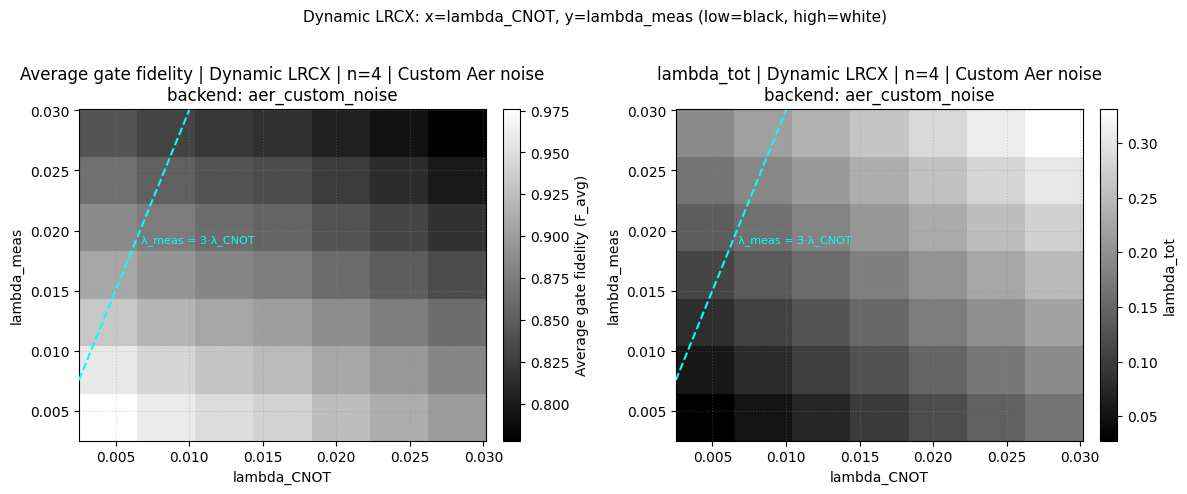

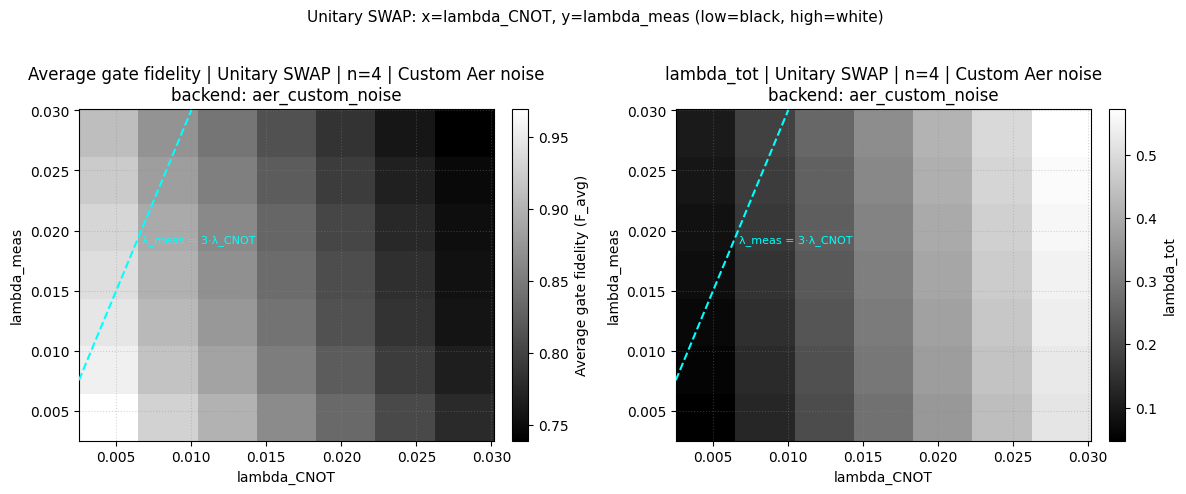

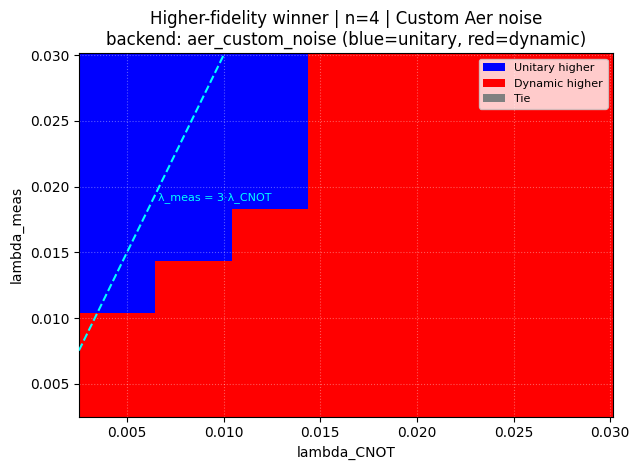

In [2]:
# Single run: N=4
TARGET_DISTANCE = 4

print(f"\n{'=' * 60}\nSingle sweep | custom noise | n={TARGET_DISTANCE}\n{'=' * 60}")

f_dyn, f_uni, l_dyn, l_uni, meta = sweep_lambda_cnot_meas_heatmaps(TARGET_DISTANCE)

plot_lambda_cnot_meas_heatmaps(f_dyn, l_dyn, meta, variant="Dynamic LRCX")
plot_lambda_cnot_meas_heatmaps(f_uni, l_uni, meta, variant="Unitary SWAP")
plot_lambda_fidelity_winner_heatmap(f_dyn, f_uni, meta)



Lambda sweep | custom noise | n=4

Custom Aer noise | backend=aer_custom_noise | distance n=4
  resources (dynamic): t_idle=0.00, N_CNOT=5, N_meas=6
  resources (unitary): t_idle=0.00, N_CNOT=17, N_meas=2
  dynamic core ops: {'h': 7, 'measure': 6, 'cx': 5, 'reset': 4, 'if_else': 2, 'barrier': 1}
  unitary core ops: {'cx': 17, 'h': 3, 'barrier': 3, 'measure': 2}
  lambda_CNOT grid: [0.0, 0.01613, 0.03226, 0.04839, 0.06452, 0.08065, 0.09677, 0.1129, 0.12903, 0.14516, 0.16129, 0.17742, 0.19355, 0.20968, 0.22581, 0.24194, 0.25806, 0.27419, 0.29032, 0.30645, 0.32258, 0.33871, 0.35484, 0.37097, 0.3871, 0.40323, 0.41935, 0.43548, 0.45161, 0.46774, 0.48387, 0.5]
  lambda_meas grid: [0.0, 0.01613, 0.03226, 0.04839, 0.06452, 0.08065, 0.09677, 0.1129, 0.12903, 0.14516, 0.16129, 0.17742, 0.19355, 0.20968, 0.22581, 0.24194, 0.25806, 0.27419, 0.29032, 0.30645, 0.32258, 0.33871, 0.35484, 0.37097, 0.3871, 0.40323, 0.41935, 0.43548, 0.45161, 0.46774, 0.48387, 0.5]
  progress 170/1024 | λ_CNOT=0.14516,

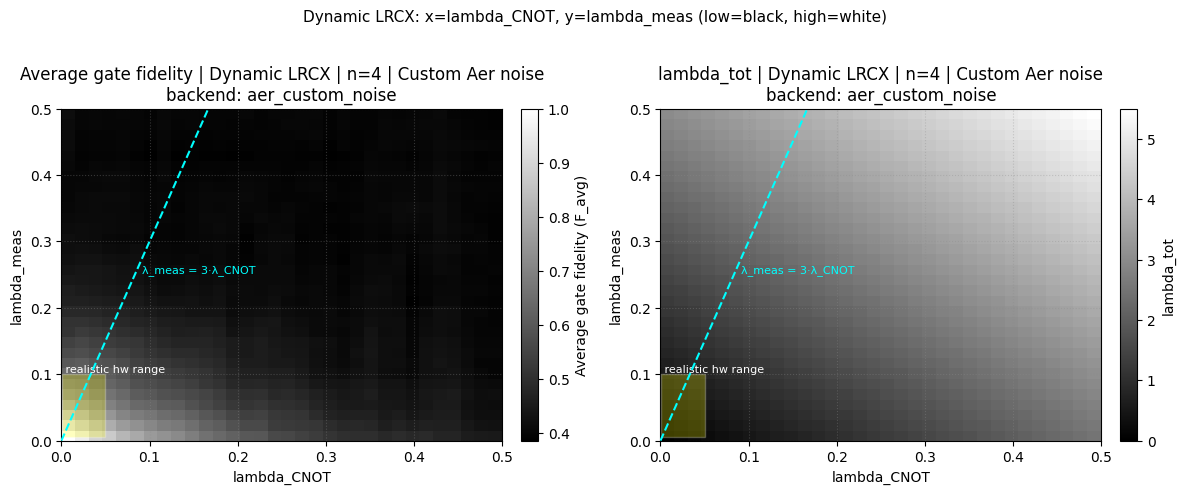

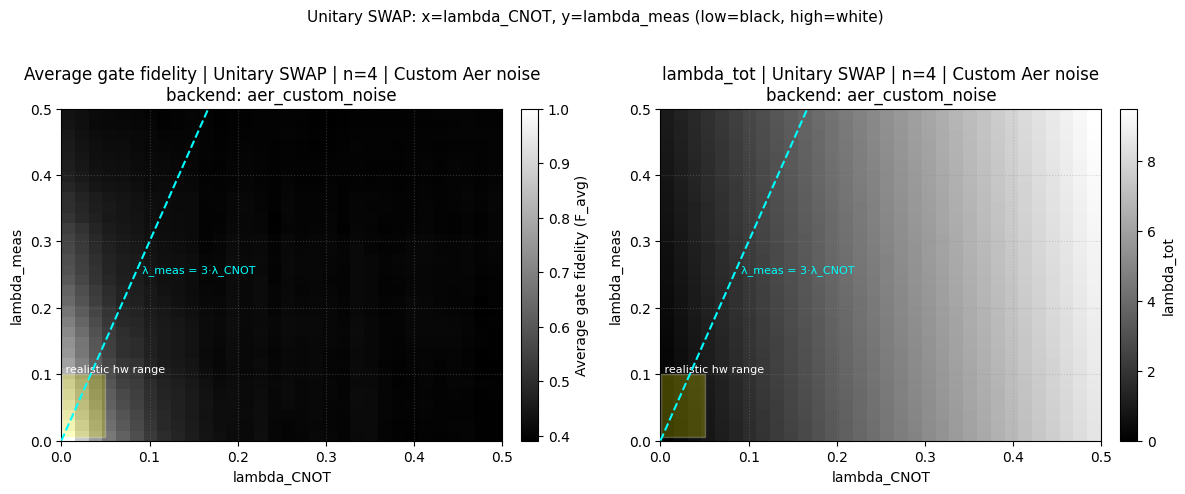

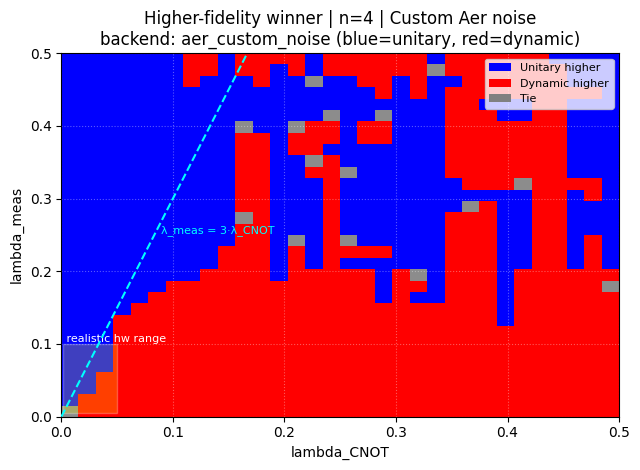

In [3]:
# Lambda sweep (32×32 grid, 0..0.5)
TARGET_DISTANCE = 4
LAMBDA_POINTS = 32

lambda_cnot_grid = np.linspace(0.0, 0.5, LAMBDA_POINTS)
lambda_meas_grid = np.linspace(0.0, 0.5, LAMBDA_POINTS)

REALISTIC_REGION = (0.001, 0.05, 0.005, 0.10)

print(f"\n{'=' * 60}\nLambda sweep | custom noise | n={TARGET_DISTANCE}\n{'=' * 60}")

f_dyn_01, f_uni_01, l_dyn_01, l_uni_01, meta_01 = sweep_lambda_cnot_meas_heatmaps(
    TARGET_DISTANCE,
    lambda_cnot_grid=lambda_cnot_grid,
    lambda_meas_grid=lambda_meas_grid,
)

# snapshot for M3 delta comparison
f_dyn_raw_snap, f_uni_raw_snap, meta_raw_snap = f_dyn_01, f_uni_01, meta_01

plot_lambda_cnot_meas_heatmaps(f_dyn_01, l_dyn_01, meta_01, variant="Dynamic LRCX", realistic_region=REALISTIC_REGION)
plot_lambda_cnot_meas_heatmaps(f_uni_01, l_uni_01, meta_01, variant="Unitary SWAP", realistic_region=REALISTIC_REGION)
plot_lambda_fidelity_winner_heatmap(f_dyn_01, f_uni_01, meta_01, realistic_region=REALISTIC_REGION)



Lambda sweep + M3 | custom noise | n=4

Custom Aer noise + M3 readout mitigation | backend=aer_custom_noise | distance n=4
  resources (dynamic): t_idle=0.00, N_CNOT=5, N_meas=6
  resources (unitary): t_idle=0.00, N_CNOT=17, N_meas=2
  dynamic core ops: {'h': 7, 'measure': 6, 'cx': 5, 'reset': 4, 'if_else': 2, 'barrier': 1}
  unitary core ops: {'cx': 17, 'h': 3, 'barrier': 3, 'measure': 2}
  lambda_CNOT grid: [0.0, 0.00794, 0.01587, 0.02381, 0.03175, 0.03968, 0.04762, 0.05556, 0.06349, 0.07143, 0.07937, 0.0873, 0.09524, 0.10317, 0.11111, 0.11905, 0.12698, 0.13492, 0.14286, 0.15079, 0.15873, 0.16667, 0.1746, 0.18254, 0.19048, 0.19841, 0.20635, 0.21429, 0.22222, 0.23016, 0.2381, 0.24603, 0.25397, 0.2619, 0.26984, 0.27778, 0.28571, 0.29365, 0.30159, 0.30952, 0.31746, 0.3254, 0.33333, 0.34127, 0.34921, 0.35714, 0.36508, 0.37302, 0.38095, 0.38889, 0.39683, 0.40476, 0.4127, 0.42063, 0.42857, 0.43651, 0.44444, 0.45238, 0.46032, 0.46825, 0.47619, 0.48413, 0.49206, 0.5]
  lambda_meas grid: [0.

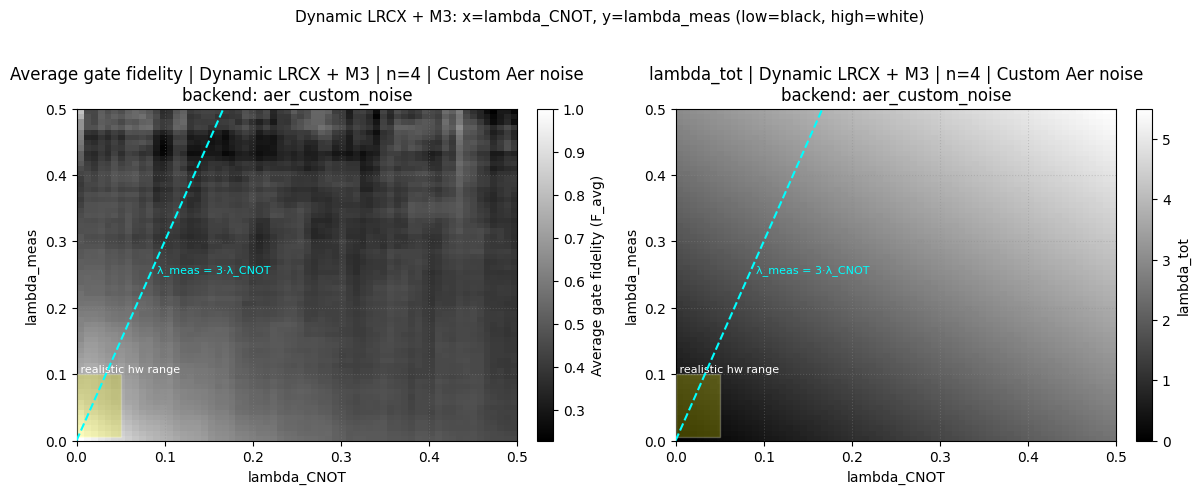

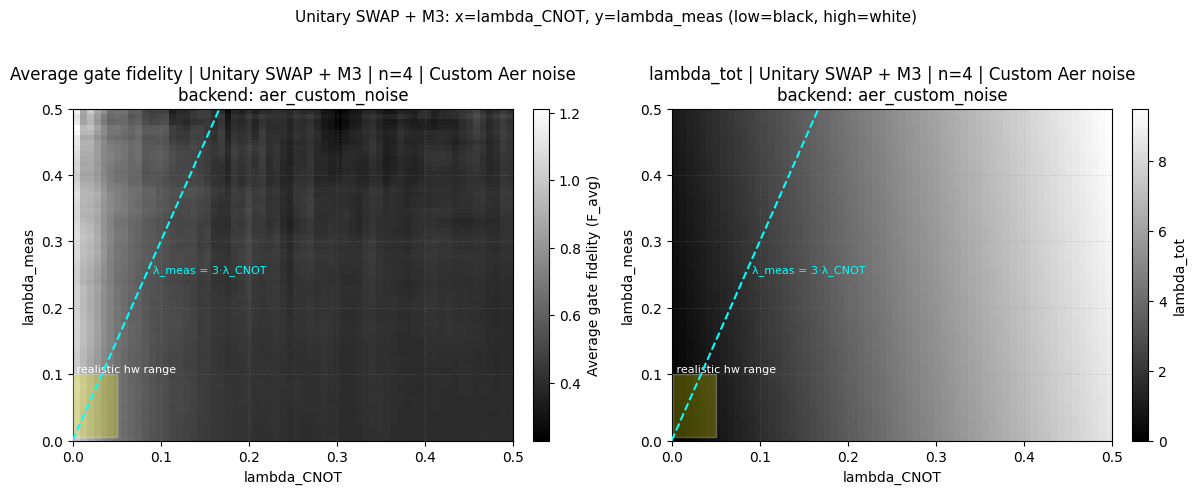


--- M3 gain vs raw (snapshot from previous cell) ---


ValueError: operands could not be broadcast together with shapes (64,64) (32,32) 

In [11]:
# Same lambda sweep with M3 readout mitigation
TARGET_DISTANCE = 4
LAMBDA_POINTS = 64

lambda_cnot_grid = np.linspace(0.0, 0.5, LAMBDA_POINTS)
lambda_meas_grid = np.linspace(0.0, 0.5, LAMBDA_POINTS)
REALISTIC_REGION = (0.001, 0.05, 0.005, 0.10)

print(f"\n{'=' * 60}\nLambda sweep + M3 | custom noise | n={TARGET_DISTANCE}\n{'=' * 60}")

f_dyn_m3, f_uni_m3, l_dyn_m3, l_uni_m3, meta_m3 = sweep_lambda_cnot_meas_heatmaps(
    TARGET_DISTANCE,
    lambda_cnot_grid=lambda_cnot_grid,
    lambda_meas_grid=lambda_meas_grid,
    apply_m3=True,
)

plot_lambda_cnot_meas_heatmaps(f_dyn_m3, l_dyn_m3, meta_m3, variant="Dynamic LRCX + M3", realistic_region=REALISTIC_REGION)
plot_lambda_cnot_meas_heatmaps(f_uni_m3, l_uni_m3, meta_m3, variant="Unitary SWAP + M3", realistic_region=REALISTIC_REGION)

if "f_dyn_raw_snap" in globals():
    print("\n--- M3 gain vs raw (snapshot from previous cell) ---")
    plot_lambda_m3_gain_heatmaps(f_dyn_raw_snap, f_dyn_m3, meta_m3, realistic_region=REALISTIC_REGION)
    plot_lambda_m3_gain_heatmaps(f_uni_raw_snap, f_uni_m3, meta_m3, realistic_region=REALISTIC_REGION)
else:
    print("Run the previous cell first to plot raw-vs-M3 delta heatmaps.")



Lambda sweep | custom noise | n=4
grid: 128×128 | λ_CNOT∈[0,0.05] | λ_meas∈[0,0.1]

Custom Aer noise | backend=aer_custom_noise | distance n=4
  resources (dynamic): t_idle=0.00, N_CNOT=5, N_meas=6
  resources (unitary): t_idle=0.00, N_CNOT=17, N_meas=2
  dynamic core ops: {'h': 7, 'measure': 6, 'cx': 5, 'reset': 4, 'if_else': 2, 'barrier': 1}
  unitary core ops: {'cx': 17, 'h': 3, 'barrier': 3, 'measure': 2}
  lambda_CNOT grid: [0.0, 0.00039, 0.00079, 0.00118, 0.00157, 0.00197, 0.00236, 0.00276, 0.00315, 0.00354, 0.00394, 0.00433, 0.00472, 0.00512, 0.00551, 0.00591, 0.0063, 0.00669, 0.00709, 0.00748, 0.00787, 0.00827, 0.00866, 0.00906, 0.00945, 0.00984, 0.01024, 0.01063, 0.01102, 0.01142, 0.01181, 0.0122, 0.0126, 0.01299, 0.01339, 0.01378, 0.01417, 0.01457, 0.01496, 0.01535, 0.01575, 0.01614, 0.01654, 0.01693, 0.01732, 0.01772, 0.01811, 0.0185, 0.0189, 0.01929, 0.01969, 0.02008, 0.02047, 0.02087, 0.02126, 0.02165, 0.02205, 0.02244, 0.02283, 0.02323, 0.02362, 0.02402, 0.02441, 0.0248,

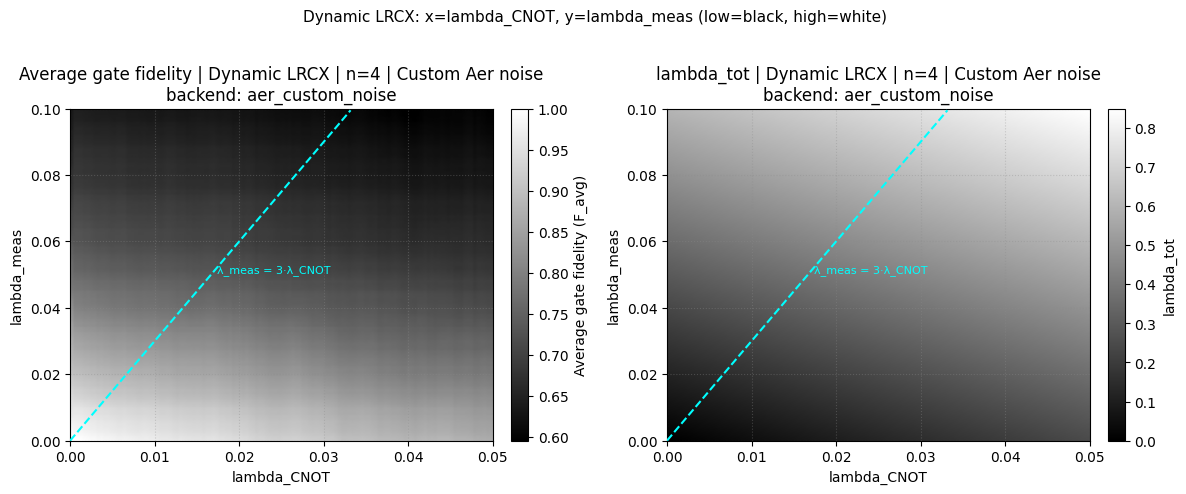

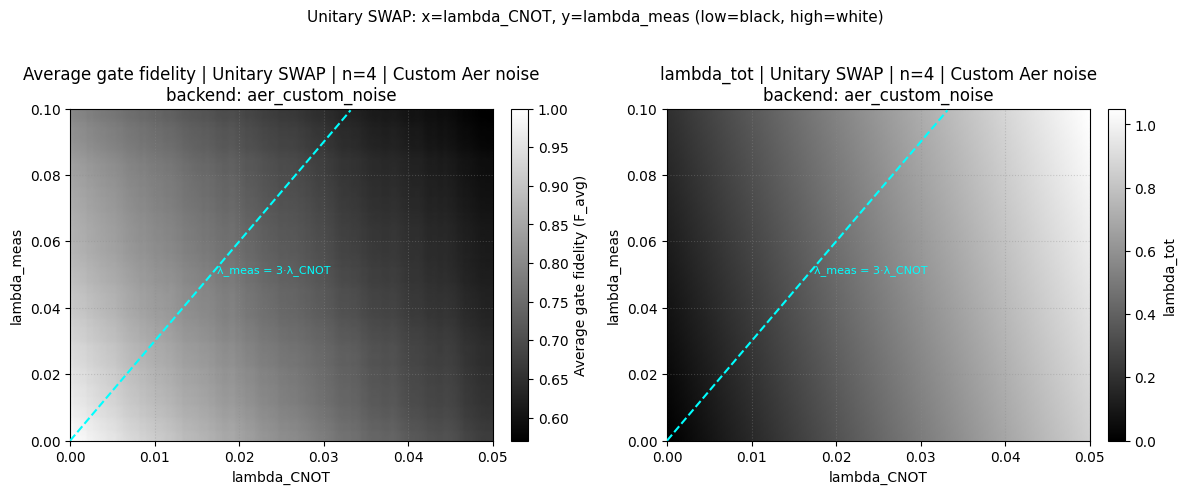

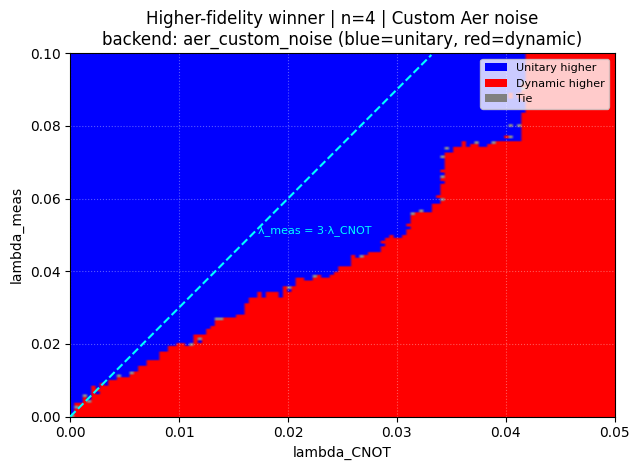

In [8]:
# Lambda sweep: lambda_CNOT in [0, 0.05], lambda_meas in [0, 0.1]
TARGET_DISTANCE = 4
LAMBDA_POINTS = 128

lambda_cnot_grid = np.linspace(0.0, 0.05, LAMBDA_POINTS)
lambda_meas_grid = np.linspace(0.0, 0.1, LAMBDA_POINTS)

print(f"\n{'=' * 60}\nLambda sweep | custom noise | n={TARGET_DISTANCE}\n{'=' * 60}")
print(f"grid: {LAMBDA_POINTS}×{LAMBDA_POINTS} | λ_CNOT∈[0,0.05] | λ_meas∈[0,0.1]")

f_dyn_01, f_uni_01, l_dyn_01, l_uni_01, meta_01 = sweep_lambda_cnot_meas_heatmaps(
    TARGET_DISTANCE,
    lambda_cnot_grid=lambda_cnot_grid,
    lambda_meas_grid=lambda_meas_grid,
)

plot_lambda_cnot_meas_heatmaps(f_dyn_01, l_dyn_01, meta_01, variant="Dynamic LRCX")
plot_lambda_cnot_meas_heatmaps(f_uni_01, l_uni_01, meta_01, variant="Unitary SWAP")
plot_lambda_fidelity_winner_heatmap(f_dyn_01, f_uni_01, meta_01)
